### DBCV custom implementation

In [64]:
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans, HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import igraph as ig

from scipy.stats import multivariate_normal
from scipy.spatial.distance import pdist, squareform

import hdbscan
import hdbscan.validity
from kneed import KneeLocator

sns.set_theme()
plt.rcParams['image.cmap'] = 'tab10'

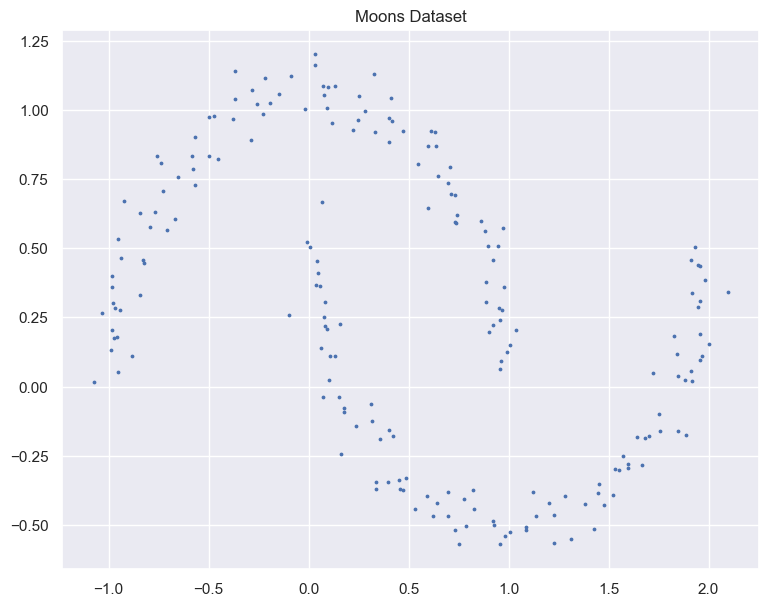

In [65]:
# create moon dataset
X, y = make_moons(n_samples=200,shuffle=True ,noise=0.06, random_state=12)
X[:,1][y==0] += 0.05

# plot the make moons data
plt.figure(figsize=(9,7))
plt.scatter(X[:,0],X[:,1], s=3)
plt.title("Moons Dataset")
plt.show()

In [66]:
# get the kmeans clustering of the data
kmeans = KMeans(n_clusters=2, n_init='auto', random_state=12)
kmeans = kmeans.fit(X)

c:\Users\Sub\anaconda3\envs\train_dl\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [67]:
CLR_MP = {
    0:'red',
    1:'green',
    2:'blue',
    3:'yellow',
    -1:'black'
}

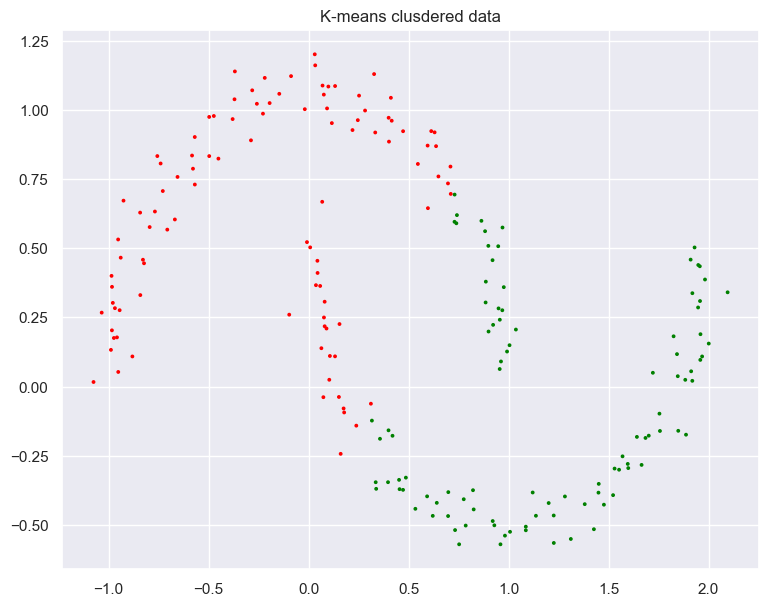

In [68]:
# plot the kmeans clusted data
colors = [CLR_MP[label] for label in kmeans.labels_]
plt.figure(figsize=(9,7))
plt.scatter(X[:,0], X[:,1], c=colors, s=3)
plt.title("K-means clusdered data")
plt.show()

In [69]:
silhouette_score(X,kmeans.labels_)

0.4829669889521878

### DBCV

In [70]:
# Get the kmeans label
labels = kmeans.labels_

# choose metric
DIST_FUNC = 'euclidean'
NUM_FEATURES = 2
IGNORE_CORE = False

if DIST_FUNC == 'precomputed':
    n_samples = X.shape[0]
    n_features = DIST_FUNC
    dist = X
else:
    n_samples = X.shape[0]
    n_features = X.shape[1]
    dist = pdist(X, DIST_FUNC)
    dist = squareform(dist)

In [71]:
# core distance calculation

core_dist = np.empty(n_samples)


# Dict for cluster index
cluster_point_index = {}

# Get all unique cluster
unique_cluster = np.unique(labels)
unique_cluster = [cluster for cluster in unique_cluster if cluster != -1]

if not IGNORE_CORE:

    # get through all the clusters:
    # all the clusters for core points in single iteration
    for label in unique_cluster:

        # get the mask corresponding to this cluster
        cluster_id = np.where(labels==label)[0]

        # store this cluster id in cluster point index
        cluster_point_index[label] = cluster_id

        # get number of points in cluster
        num_cluster_points = cluster_id.shape[0]

        # get the cluster points from the data
        cluster_core_dist = dist[np.ix_(cluster_id, cluster_id)]

        cluster_core_dist[cluster_core_dist != 0] = np.power(
            cluster_core_dist[cluster_core_dist != 0], -n_features
        )

        cluster_core_dist = np.sum(cluster_core_dist, axis=1)/(num_cluster_points - 1)
        cluster_core_dist = np.power(cluster_core_dist , -1/n_features)

        # store the core distance
        core_dist[cluster_id] = cluster_core_dist
    
    # create mutual reachability distance
    max_core_dist = np.max(
        np.meshgrid(core_dist, core_dist),
        axis=0
    )

    mut_reach_dist = np.max(
        [max_core_dist, dist],
        axis=0
    )

else:

    for  label in unique_cluster:

        clust_ids = np.where(labels==label)[0]

        cluster_point_index[label] = clust_ids

    mut_reach_dist = dist

In [72]:
# cluster density sparseness

# dict to store density of sparseness of a cluster
cluster_dens_spar = {}

# Dict to store cluster internal nodes
cluster_internal_nodes = {}

# iterate through each label
# create density sparsness 

for label in unique_cluster:

    # get the id of points in for current label
    points_id = cluster_point_index[label]

    # get the mutual reachability  distance this cluster
    clust_mut_reach_dist = mut_reach_dist[np.ix_(points_id, points_id)].copy()
    np.fill_diagonal(clust_mut_reach_dist, 0)

    g = ig.Graph.Weighted_Adjacency(clust_mut_reach_dist, mode='undirected')

    # calculate spanning tree
    mst = g.spanning_tree(weights=g.es['weight'])
    mst_adj = mst.get_adjacency(attribute='weight')

    curr_MST = np.array(mst_adj.data)

    # get the degree of the node
    node_degree = np.array((curr_MST > 0).sum(axis=0)).flatten()

    # find index of all internal nodes
    # (Nodes which has minimum degree greater than 1)
    internal_index_node = np.where(node_degree > 1)[0]

    # max edge weight in MST is density sparseness of cluster
    # max edge is taken from set of internal nodes
    cluster_dens_spar[label] = (curr_MST[np.ix_(internal_index_node, internal_index_node)]).max()

    # save all internal node of a cluster
    cluster_internal_nodes[label] = points_id[internal_index_node]

In [81]:
cluster_dens_spar

{0: 0.4476775404345504, 1: 0.45776262472976065}

In [74]:
# cluster density seperation

# get all the cluster pairs
clust_combs = list(combinations(unique_cluster, 2))

# dataframe to store density separation
# between cluster pair
distance_df = pd.DataFrame(
    np.full([len(unique_cluster), len(unique_cluster)], fill_value=0),
    index=unique_cluster,
    columns=unique_cluster
)

# Calculate the density seperation for
# cluster pairs

for clust_comb in clust_combs:

    # get the cluster id
    clust1 = clust_comb[0]
    clust2 = clust_comb[1]

    # get the cluster internal node
    clust1_internal_node = cluster_internal_nodes[clust1]
    clust2_internal_node = cluster_internal_nodes[clust2]

    # Minimum reachability distance between cluster internal node
    # is cluster density separation
    curr_clust_sep = (mut_reach_dist[np.ix_(clust2_internal_node, clust1_internal_node)]).min()

    # write distance to symetrical distance
    distance_df.loc[clust1, clust2] = curr_clust_sep
    distance_df.loc[clust2, clust1] = curr_clust_sep

C:\Users\Sub\AppData\Local\Temp\ipykernel_16936\175986100.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2380967626210491' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  distance_df.loc[clust1, clust2] = curr_clust_sep
C:\Users\Sub\AppData\Local\Temp\ipykernel_16936\175986100.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2380967626210491' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  distance_df.loc[clust2, clust1] = curr_clust_sep


In [80]:
distance_df

,0,1
0,0.000000,0.238097
1,0.238097,0.000000


In [84]:
# Calculate validity cofficient for all cluster
clust_val_coeff = {}

for label in unique_cluster:

    sep = distance_df.loc[label].max()
    dens_spar = cluster_dens_spar[label]
    
    curr_vc_nom = sep - dens_spar
    curr_vc_den = sep + dens_spar

    clust_val_coeff[label] = curr_vc_nom/curr_vc_den

# final calculation
final_vc = 0

for label in unique_cluster:

    final_vc += clust_val_coeff[label] * (cluster_point_index[label].shape[0]/n_samples)
    print("Validity index for cluster {} is {}.".format(label, clust_val_coeff[label]))

print("Mean Validity index is : {}".format(final_vc))

Validity index for cluster 0 is -0.305611885542625.
Validity index for cluster 1 is -0.31567564669206577.
Mean Validity index is : -0.31059344731159816


In [79]:
# HDBSCAN library validity index
hdbscan.validity.validity_index(X=X,
                                labels=kmeans.labels_,
                                metric='euclidean',
                                per_cluster_scores=True)

(-0.3124560335235598, array([-0.30487537, -0.32018984]))